In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)


2.6.0+cu124
True
12.4


In [4]:
!pip install -q datasets

In [5]:
from datasets import load_dataset
emotions = load_dataset("emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [6]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [7]:
train_set = emotions["train"]
train_set

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [8]:
train_set[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [9]:
emotions.set_format("pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


Function to name the labels

In [10]:
def label_convertor(row):
  return emotions["train"].features["label"].int2str(row)

In [11]:
df["label_name"]=df["label"].apply(label_convertor)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Data Visualization

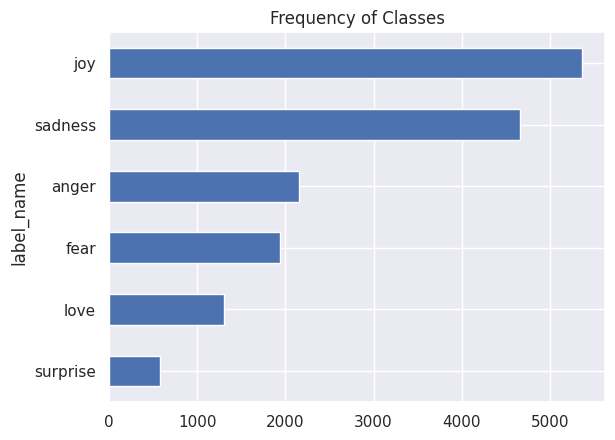

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [13]:
emotions.reset_format()

Data Preprocessing

Tokenization using Hugging Face libraries

In [14]:
!pip install -q transformers

Distil-BERT Tokenizer

In [15]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(checkpoint)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [16]:
def tokenize_function(batch):
  return tokenizer(batch["text"], padding=True, truncation= True)

In [17]:
print(tokenize_function(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [18]:
tokenized_datasets = emotions.map(tokenize_function, batched = True, batch_size = None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [19]:
print(tokenized_datasets["train"].column_names)

['text', 'label', 'input_ids', 'attention_mask']


AutoModelForSequenceClassification for Fine tuning the model according to our Dataset

In [23]:
from transformers import AutoModelForSequenceClassification
import torch
checkpoint = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = (AutoModelForSequenceClassification.from_pretrained(checkpoint,num_labels = 6).to(device))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels,preds, average = "weighted")
  acc = accuracy_score(labels,preds)
  return {"accuracy":acc, "f1":f1}

In [28]:
from huggingface_hub import notebook_login
notebook_login()

Token has not been saved to git credential helper.


In [50]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="finetuning-emotion-model",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_eval_batch_size=64,
    per_device_train_batch_size=64,
    weight_decay=0.01,
    eval_strategy="epoch",
    disable_tqdm=False,
    push_to_hub=True,
    report_to="none"
)


In [52]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

<ipython-input-52-df0ee0b1c620>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [53]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.174776,0.941500,0.941813
2,0.064900,0.162545,0.939500,0.939703


TrainOutput(global_step=500, training_loss=0.06488053131103516, metrics={'train_runtime': 237.6368, 'train_samples_per_second': 134.659, 'train_steps_per_second': 2.104, 'total_flos': 720342861696000.0, 'train_loss': 0.06488053131103516, 'epoch': 2.0})

In [54]:
trainer.push_to_hub(commit_message = "Training Completed")

CommitInfo(commit_url='https://huggingface.co/avanthika06/finetuning-emotion-model/commit/019ccb0203b87bc48e1b5e55ecba7759a62065ed', commit_message='Training Completed', commit_description='', oid='019ccb0203b87bc48e1b5e55ecba7759a62065ed', pr_url=None, repo_url=RepoUrl('https://huggingface.co/avanthika06/finetuning-emotion-model', endpoint='https://huggingface.co', repo_type='model', repo_id='avanthika06/finetuning-emotion-model'), pr_revision=None, pr_num=None)

In [55]:
from transformers import pipeline
classifier = pipeline("text-classification",
                      model = "avanthika06/finetuning-emotion-model")

config.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


In [57]:
pred = classifier(["I am sad"],return_all_scores=True)

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


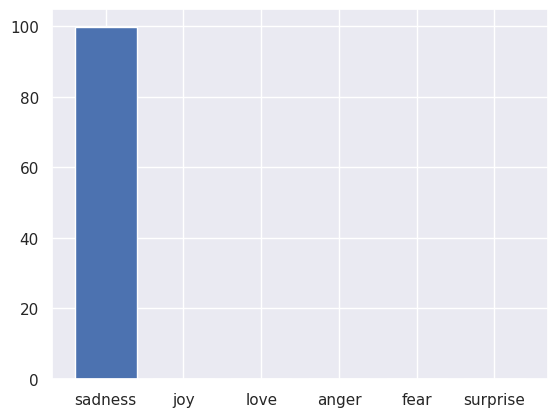

In [60]:
import pandas as pd
labels = emotions["train"].features["label"].names
df = pd.DataFrame(pred[0])
plt.bar(labels, 100 * df["score"])
plt.show()